In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\devso\causal-ml-project\data\processed\df_with_ite.csv")

# load your saved processed dataframe if needed
# OR recompute ITE_X here (better for reproducibility)

# assuming df already has:
# 'ITE_X', 'treatment', 'conversion'

In [5]:
df.columns

Index(['recency', 'history', 'mens', 'womens', 'newbie', 'conversion',
       'treatment', 'history_segment_2) $100 - $200',
       'history_segment_3) $200 - $350', 'history_segment_4) $350 - $500',
       'history_segment_5) $500 - $750', 'history_segment_6) $750 - $1,000',
       'history_segment_7) $1,000 +', 'zip_code_Surburban', 'zip_code_Urban',
       'channel_Phone', 'channel_Web', 'ITE_T', 'ITE_LR', 'ITE_RF'],
      dtype='str')

In [6]:
df['uplift_segment'] = pd.qcut(df['ITE_LR'], q=4, labels=False)

segment_summary = df.groupby('uplift_segment')['conversion'].mean()

print(segment_summary)

uplift_segment
0    0.009125
1    0.006938
2    0.007812
3    0.012251
Name: conversion, dtype: float64


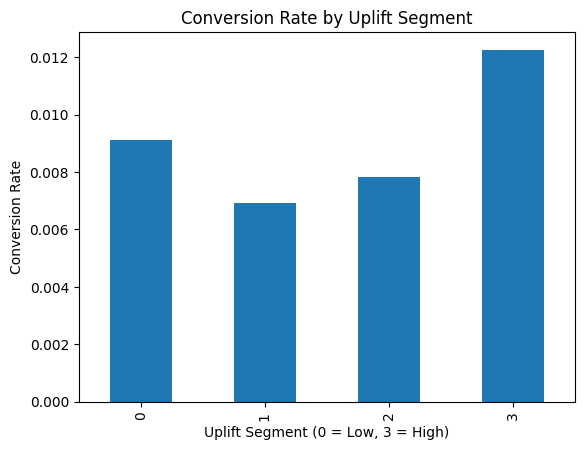

In [7]:
import matplotlib.pyplot as plt

segment_summary.plot(kind='bar')
plt.title("Conversion Rate by Uplift Segment")
plt.xlabel("Uplift Segment (0 = Low, 3 = High)")
plt.ylabel("Conversion Rate")
plt.show()

In [9]:
top_20 = df.sort_values(by='ITE_LR', ascending=False).head(int(0.2 * len(df)))

treated = top_20[top_20['treatment'] == 1]['conversion'].mean()
control = top_20[top_20['treatment'] == 0]['conversion'].mean()

print("Uplift in Top 20%:", treated - control)

Uplift in Top 20%: 0.007809050043384838


In [11]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['conversion', 'treatment', 'ITE_LR', 'uplift_segment'])

y = df['ITE_LR']

surrogate = RandomForestRegressor()
surrogate.fit(X, y)

RandomForestRegressor()

In [ ]:
import shap

explainer = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

c:\Users\devso\causal-ml-project\venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
